# Model Evaluation

This notebook evaluates machine learning models used for predicting employee attrition in the healthcare sector.

Evaluation metrics include:
- Confusion Matrix
- Precision
- Recall
- F1-score
- ROC Curve
- ROC-AUC Score

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [13]:
import pandas as pd

employee_df = pd.read_csv('../data/watson_healthcare.csv')

attr_dictionary = {
    'Yes': 1,
    'No': 0
}

employee_df['AttritionNum'] = employee_df['Attrition'].map(attr_dictionary)

employee_df = employee_df.drop(['Attrition','EmployeeID'], axis=1)

column_names = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'Over18',
    'OverTime'
]

int_cols = employee_df.drop(column_names, axis=1)

obj_columns = employee_df.filter(column_names, axis=1)

obj_columns_one_hot = pd.get_dummies(
    obj_columns,
    drop_first=True
)

employee_df_new = pd.concat(
    [int_cols, obj_columns_one_hot],
    axis=1
)

In [14]:
X =  employee_df_new.drop(['AttritionNum'], axis=1)
Y = employee_df_new.filter(['AttritionNum'], axis=1)

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.25,random_state=4
)

In [15]:
RF_clf = RandomForestClassifier()

RF_clf.fit(X_train,Y_train)

test_pred_RF = RF_clf.predict(X_test)

c:\Users\soora\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


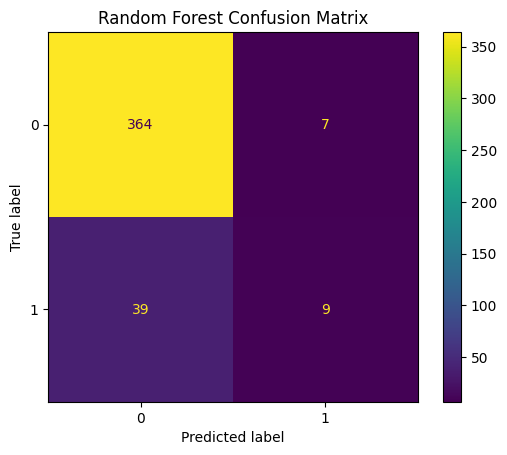

In [16]:
cm = confusion_matrix(Y_test, test_pred_RF)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [17]:
print(classification_report(Y_test, test_pred_RF))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       371
           1       0.56      0.19      0.28        48

    accuracy                           0.89       419
   macro avg       0.73      0.58      0.61       419
weighted avg       0.86      0.89      0.87       419



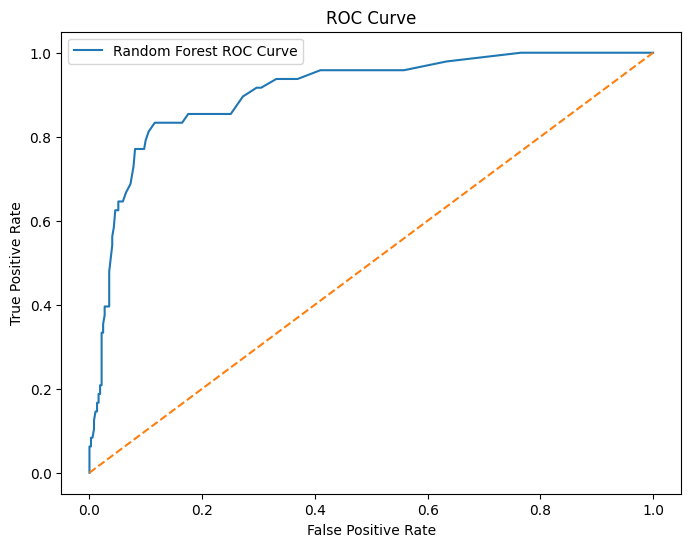

In [18]:
y_prob_RF = RF_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, y_prob_RF)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='Random Forest ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [19]:
auc_score = roc_auc_score(Y_test, y_prob_RF)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9064746181491463


## Observation

The Random Forest model achieved strong classification performance with a high ROC-AUC score, indicating good ability to distinguish between employees likely to leave and employees likely to stay.

The confusion matrix also shows that the model correctly classified most employee attrition cases.